# Воркшоп: Препроцессинг текстов

В этом ноутбуке будем обсуждать, как подготовить текст для аналитики и поисковых систем.

In [1]:
#@title Импорты
! pip install telethon==1.41.2
! pip install qdrant_client
! pip install langchain_huggingface langchain-qdrant

import pandas as pd
import matplotlib.pyplot as plt
import random
import torch

random.seed(42)

from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.9/744.9 kB 1.6 MB/s eta 0:00:00a 0:00:01
Using cached rsa-4.9.1-py3-none-any.whl (34 kB)
Using cached pyasn1-0.6.1-py3-none-any.whl (83 kB)
  Created wheel for pyaes: filename=pyaes-1.6.1-py3-none-any.whl size=26422 sha256=46c29322cb57100acc9a37f1f8ef778ade94b8e9a26a84443c64dc4b7aed33de
  Stored in directory: /Users/sergey/Library/Caches/pip/wheels/33/13/e9/ef9894385084d8e4fab38f5f83afda49a3d593d8afc907c8fd
Successfully built pyaes

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0

/Users/sergey/Projects/GigaSchool/llm-engineer/venv/lib/python3.9/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


cpu


In [ ]:
#@title Введите ваши токены
api_id = "29508696" #@param{type:"string"}
api_id = int(api_id)
api_hash = '53db3202338934b8e1743a17503a37d6' #@param{type:"string"}
session_name = "workshop_preprocessing_v2"

Error in callback <function set_css at 0x107aff8b0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 17e002190, raw_cell="#@title Введите ваши токены
api_id = @param{type:".." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/sergey/Projects/GigaSchool/llm-engineer/module03/theme01/data_preprocessing.ipynb#W3sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

SyntaxError: invalid syntax (3783455679.py, line 2)

In [ ]:
#@title Запуск клиента Telegram
from telethon import TelegramClient, events, sync
from telethon.tl.types import PeerChannel

client = TelegramClient(session_name, api_id, api_hash)


In [ ]:
#@title Парсинг данных
async def fetch_messages(channel_username: str, limit: int = 200):
    await client.start()
    entity = await client.get_entity(channel_username)
    msgs = []
    async for msg in client.iter_messages(entity, limit=limit):
        if msg.text is not None and msg.text != '':
            msgs.append({
                'id': msg.id,
                'date': msg.date.isoformat(),
                'text': msg.text,
            })
    await client.disconnect()
    return msgs

channel_name = 'gonzo_ML' #@param{type:"string"}
limit = 2000 #@param{type:"string"}
limit = int(limit)

out = await fetch_messages(channel_name, limit=limit)
print(f'Fetched {len(out)} messages')

Please enter your phone (or bot token): 89260182307
Please enter the code you received: 96251
Please enter your password: ··········
Signed in successfully as Dasha Andreeva [GMT+9]; remember to not break the ToS or you will risk an account ban!
Fetched 830 messages


In [ ]:
df = pd.read_csv('/content/gonzo_dump.csv')

# Давайте проверим, что мы тут напарсили

(спойлер: данные будут мусорные, и как с этим работать вообще не понятно)

In [ ]:
#df = pd.DataFrame(out)
df.head(5)

,Unnamed: 0,id,date,text,word_count
0,0,4058,2025-09-24T22:40:11+00:00,Что-то интересное:\n\nHappy to release Meta Co...,245
1,1,4057,2025-09-23T11:44:54+00:00,Что почитать в дороге,4
2,2,4055,2025-09-22T19:18:08+00:00,Когда же уже R2 наконец?!\n\nDeepSeek-V3.1 → D...,33
3,3,4053,2025-09-22T10:49:48+00:00,"Мы уже писали про варианты JEPA, например, JEP...",42
4,4,4040,2025-09-21T22:40:06+00:00,* **Самодистилляция:** Ещё более удивительно...,232


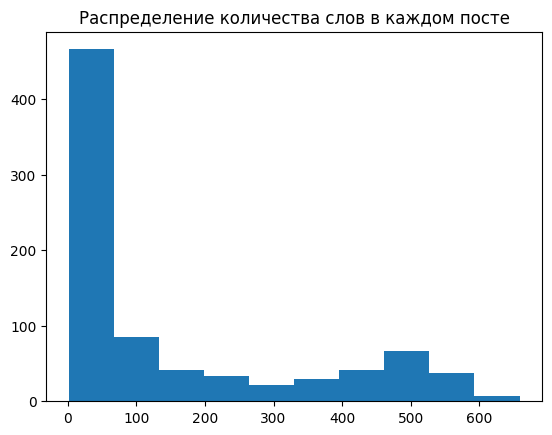

In [ ]:
df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

В конце концов у нас достаточно много коротких постов (до 100 слов), но есть и достаточно длинные разборы статей (больше 300 слов). Давайте глянем примеры по каждому:

In [ ]:
shortest = df[df['word_count'] < 100].sample(5, random_state=42)['text'].values

for i, text in enumerate(shortest):
    print(f"Пост номер {i + 1}: {text}")
    print()

Пост номер 1: Для тех, кто не в теме, напомню, как оно было на самом деле.

Пост номер 2: We introduce Starling-7B, an open large language model (LLM) trained by Reinforcement Learning from AI Feedback (RLAIF). The model harnesses the power of our new GPT-4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling-7B-alpha scores 8.09 in MT Bench with GPT-4 as a judge, outperforming every model to date on MT-Bench except for OpenAI’s GPT-4 and GPT-4 Turbo.

https://starling.cs.berkeley.edu

Пост номер 3: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Пост номер 4: Первые инкарнации вроде [Med-PaLM 2](https://sites.research.google/med-palm) в здравоохранении, [BloombergGPT](https://arxiv.org/abs/2303.17564) в финансах, [Sec-PaLM 2](https://cloud.google.com/blog/products/identity-security/security-ai-next23) в безопасности показывают, что р

In [ ]:
longest = df[df['word_count'] > 400].sample(5, random_state=42)['text'].values

for i, text in enumerate(longest):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

Пост номер 1: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

AMD конечно интересны со своей серией MI, в топовой модели MI325

Наша главная проблема в любой предобработке текста: отделить содержательные тексты от мусора. Да, критерии "что есть мусор" в каждом случае будут разные, но от самого процесса нам никуда не деться.



# Chunking

Теперь давайте попробуем посмотреть разные способы разделения текста на куски (они же чанки, от английского chunk). Раасмотрим на примере удобной либы `chonkie`:

In [ ]:
#скачаем, если нужно
!pip install chonkie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 998.9/998.9 kB 55.6 MB/s eta 0:00:00


В библиотеке chonkie посмотрим на следующие методы:

In [ ]:
from chonkie import TokenChunker, SentenceChunker, RecursiveChunker, RecursiveRules, SemanticChunker

**Начнём с `TokenChunker`:**

Самый простой чанкер, который разобьёт наш текст ровно по токенам; поддерживает overlap (пересечение чанков). Это хорошо, когда нам нужен чёткий контроль токенов и его количества, особенно если мы хотим контролировать расходы, работая со внешними нейросетями, однако мы можем потерять часть смысла, разрезав слово на две части.

Подробную документацию можно почитать тут: [TokenChunker](https://docs.chonkie.ai/python-sdk/chunkers/token-chunker)

In [ ]:
token_chunker = TokenChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    chunk_overlap=64
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 batches chunked [00:00<00:00, 851.88batch/s] 🌱


Текст номер 1:
Размер чанка: 20
Текст чанка: Для тех, кто не в теме, напомню, как оно было на самом деле.

Текст номер 2:
Размер чанка: 142
Текст чанка: We introduce Starling - 7B, an open large language model ( LLM ) trained by Reinforcement Learning from AI Feedback ( RLAIF ). The model harnesses the power of our new GPT - 4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling - 7B - alpha scores 8. 09 in MT Bench with GPT - 4 as a judge, outperforming every model to date on MT - Bench except for OpenAI s GPT - 4 and GPT - 4 Turbo. https : / / starling. cs. berkeley. edu

Текст номер 3:
Размер чанка: 74
Текст чанка: И ещё до кучи про свежего Клода https : / / twitter. com / hahahahohohe / status / 1765088860592394250? t = PHcRVaE6GFXLDXpBVQE - IA & s = 19 Это безумно круто ( если правда )

Текст номер 4:
Размер чанка: 125
Текст чанка: Первые инкарнации вроде [ Med - PaLM 2 ] ( https : / / sites. research. google / med - palm ) в здравоохр

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 batches chunked [00:00<00:00, 165.63batch/s] 🌱


Текст номер 1:
Размер чанка: 256
Текст чанка: Когда я в 2018 - м делал свой обзор железа для глубокого обучения ( https : / / moocaholic. medium. com / hardware - for - deep - learning - part - 3 - gpu - 8906c1644664 ), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие - то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли. AMD кон

**Дальше попробуем `SentenceChunker`**:

Этот чанкер обрезает по границам предложения, собирая предложения, пока мы не достигнем целевого размера. Таким образом мы сохраняем целостность одной мысли, не разрезая предложения, как в чанкере выше. Тем не менее, проблема разделения смысла остаётся, так как он может быть размазан по нескольким предложениям, а чанки могут получиться неконсистентными (одни покороче, другие подлиннее) -- из-за этого может быть тяжело следить за количеством токенов, попадающих в модель, а потому может быть тяжелее отслеживать биллинг.

Такой чанкер будет хорош для текстов, где каждое предложение является более-менее оконченной мыслью, преложения либо короткие, либо хотя бы примерно одного размера (не стоит использовать для чанкирования "Войны и Мира"). Кроме того, иногда имеет смысл иметь fallback на случай превышения общего размера токенов, которые мы куда-то передаём (например, топ-5 чанков передаём в LLM)

Документацию можно глянуть тут: [Sentence Chunker](https://docs.chonkie.ai/python-sdk/chunkers/sentence-chunker)

In [ ]:
token_chunker = SentenceChunker(
    tokenizer_or_token_counter="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    chunk_overlap=64
)

In [ ]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  5.43doc/s] 🌱


Текст номер 1:
Размер чанка: 18
Текст чанка: Для тех, кто не в теме, напомню, как оно было на самом деле.

Текст номер 2:
Размер чанка: 140
Текст чанка: We introduce Starling-7B, an open large language model (LLM) trained by Reinforcement Learning from AI Feedback (RLAIF). The model harnesses the power of our new GPT-4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling-7B-alpha scores 8.09 in MT Bench with GPT-4 as a judge, outperforming every model to date on MT-Bench except for OpenAI’s GPT-4 and GPT-4 Turbo.

https://starling.cs.berkeley.edu

Текст номер 3:
Размер чанка: 72
Текст чанка: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Текст номер 4:
Размер чанка: 123
Текст чанка: Первые инкарнации вроде [Med-PaLM 2](https://sites.research.google/med-palm) в здравоохранении, [BloombergGPT](https://arxiv.org/abs/2303.17564) в финан

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  8.28doc/s] 🌱


Текст номер 1:
Размер чанка: 112
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. 

Размер чанка: 49
Текст чанка: Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? 

Размер чанка: 59
Текст чанка: Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. 

Размер чанка: 117
Текст чанка: NVIDIA долго старалась разделить эти два рынка, и вот сейч

**Теперь `SemantcicChunker`**:

Сохраняем смыслы внутри чанка: делим так, чтобы (по возможности) один смысл == один чанк. Группируем соседние элементы до тех пор, пока внутри семантическая когерентность высокая.

Чанки согласованы семантически -> лучше семантический ретрив; меньше шумных/неинформативных чанков.

В недавних обновлениях библиотеки добавили объединение даже не-соседствующих кусков, и теперь для этого нужно для этого изменить параметр `skip_window` (`0`: склеиваем только последовательные, `1`: группируем разрозненные). Это наследие метода `SDPMChunker` (Semantic Double-Pass Merge), который был убран в недавнем обновлении библиотеки. Если вам важно соседство частей, обратите внимание на этот параметр.

Таким образом, можно использовать этот метод для длинных разнотемных текстов, где темы/подтемы переплетаются (отчёты, форумы, собранные логи, образовательные статьи).

Документация лежит [тут](https://docs.chonkie.ai/python-sdk/chunkers/semantic-chunker).

In [ ]:
token_chunker = SemanticChunker(
    embedding_model="sergeyzh/rubert-mini-frida",
    threshold=0.5,                   # Similarity threshold (0-1) or (1-100) or "auto"
    chunk_size=512,
    min_sentences=1                  # Минимальный размер чанка (в предложениях)
)

modules.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config_sentence_transformers.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/129M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

In [ ]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  6.30doc/s] 🌱


Текст номер 1:
Размер чанка: 18
Текст чанка: Для тех, кто не в теме, напомню, как оно было на самом деле.

Текст номер 2:
Размер чанка: 140
Текст чанка: We introduce Starling-7B, an open large language model (LLM) trained by Reinforcement Learning from AI Feedback (RLAIF). The model harnesses the power of our new GPT-4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling-7B-alpha scores 8.09 in MT Bench with GPT-4 as a judge, outperforming every model to date on MT-Bench except for OpenAI’s GPT-4 and GPT-4 Turbo.

https://starling.cs.berkeley.edu

Текст номер 3:
Размер чанка: 72
Текст чанка: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Текст номер 4:
Размер чанка: 123
Текст чанка: Первые инкарнации вроде [Med-PaLM 2](https://sites.research.google/med-palm) в здравоохранении, [BloombergGPT](https://arxiv.org/abs/2303.17564) в финан

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  9.10doc/s] 🌱


Текст номер 1:
Размер чанка: 149
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. 

Размер чанка: 157
Текст чанка: Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

**И теперь `RecursiveChunker`**:

Метод разбивает документ по иерархическим уровням (заголовки → параграфы → предложения → токены). Плюс: сохраняет структуру и семантические границы; минус: требует правил для разных форматов и чуть сложнее поддерживать. Используйте для технических доков, markdown/HTML, книг и любых структурированных текстов. Удобно, если формат неизменен, потому что иначе правила могут заскейлиться некорректно или быть неудобными для конкретного формата текста.

Вместе с тем, очевидно, что чанкер не делит текст на куски хоть сколько-то консистентных размеров, так что лучше иметь fallback'и на превышение размера контекстов.

Документацию о RecursiveChunker можно почитать [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker), а о правилах [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker#additional-information)


In [ ]:
from chonkie import RecursiveRules, RecursiveChunker

token_chunker = RecursiveChunker(
    tokenizer_or_token_counter="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    rules=RecursiveRules(),
    min_characters_per_chunk=24,
)

In [ ]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  9.99doc/s] 🌱


Текст номер 1:
Размер чанка: 18
Текст чанка: Для тех, кто не в теме, напомню, как оно было на самом деле.

Текст номер 2:
Размер чанка: 140
Текст чанка: We introduce Starling-7B, an open large language model (LLM) trained by Reinforcement Learning from AI Feedback (RLAIF). The model harnesses the power of our new GPT-4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling-7B-alpha scores 8.09 in MT Bench with GPT-4 as a judge, outperforming every model to date on MT-Bench except for OpenAI’s GPT-4 and GPT-4 Turbo.

https://starling.cs.berkeley.edu

Текст номер 3:
Размер чанка: 72
Текст чанка: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Текст номер 4:
Размер чанка: 123
Текст чанка: Первые инкарнации вроде [Med-PaLM 2](https://sites.research.google/med-palm) в здравоохранении, [BloombergGPT](https://arxiv.org/abs/2303.17564) в финан

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00,  9.23doc/s] 🌱



Текст номер 1:
Размер чанка: 243
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.


Размер чанка: 190
Текст чанка:

Можно достать рекурсивный чанкер из готовых рецептов для разной разметки и разных языков, например, вот тут мы загружаем готовый рецепт на markdown разметку:

In [ ]:
token_chunker = RecursiveChunker.from_recipe("markdown")

v1.schema.json: 0.00B [00:00, ?B/s]

markdown_en.json: 0.00B [00:00, ?B/s]

In [ ]:
shortest_chunked = token_chunker.chunk_batch(shortest)

print()
for i, text in enumerate(shortest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00, 643.93doc/s] 🌱


Текст номер 1:
Размер чанка: 60
Текст чанка: Для тех, кто не в теме, напомню, как оно было на самом деле.

Текст номер 2:
Размер чанка: 444
Текст чанка: We introduce Starling-7B, an open large language model (LLM) trained by Reinforcement Learning from AI Feedback (RLAIF). The model harnesses the power of our new GPT-4 labeled ranking dataset, Nectar, and our new reward training and policy tuning pipeline. Starling-7B-alpha scores 8.09 in MT Bench with GPT-4 as a judge, outperforming every model to date on MT-Bench except for OpenAI’s GPT-4 and GPT-4 Turbo.

https://starling.cs.berkeley.edu

Текст номер 3:
Размер чанка: 155
Текст чанка: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Текст номер 4:
Размер чанка: 396
Текст чанка: Первые инкарнации вроде [Med-PaLM 2](https://sites.research.google/med-palm) в здравоохранении, [BloombergGPT](https://arxiv.org/abs/2303.17564) в фина

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 docs chunked [00:00<00:00, 507.55doc/s] 🌱


Текст номер 1:
Размер чанка: 1985
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

AMD конечно интересны со своей

Полный список рецептов можно глянуть [тут](https://huggingface.co/datasets/chonkie-ai/recipes).

# Попробуем имплементировать это в поиск

In [ ]:
#@title Немного магии для работы поиска
#@markdown Мы расскажем о ней чуть позже, потому что сейчас хотим заострить внимание на предобработке и её влиянии на качество поиска.

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain_core.documents import Document

embed_model_name = "sergeyzh/rubert-mini-frida"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = None

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
)

documents = [Document(page_content=text) for text in df.text.values]

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

Начнём с пары простых запросов, в которых мы никак не меняли размер документов, и грузили как есть:

In [ ]:
query = "Клод"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

По запросу Клод нашлось:
Пост номер 1: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)
Пост номер 2: Антропик выкатил новую модель Claude 3.5 Sonnet

https://www.anthropic.com/news/claude-3-5-sonnet
Пост номер 3: Слайд забыл :)
Пост номер 4: А ещё выехал Claude 3 Haiku, самый маленький, шустрый и дешёвый из семейства

https://www.anthropic.com/news/claude-3-haiku


/tmp/ipython-input-2462113203.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]


In [ ]:
query = "как работать нерелевантной информацией в промпте модели?"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу как работать нерелевантной информацией в промпте модели? нашлось:

Пост номер 1: Ещё одна интересная работа про репрезентации, хорошо дополняет предыдущую (и вышла до неё). Тоже долго лежала в очереди на разбор, но уже проще через автомат прогнать, чем дальше держать. 

https://t.me/gonzo_ML_podcasts/812

Работа хорошая, показывает, что тренд на увеличение размера модели не решает проблему выучивания хороших репрезентаций, они получаются недостаточно разнообразными. Авторы предлагают свой метод обучения нескольких моделей на разных задачах и конкатенации в одну, который требует столько же вычислительных ресурсов, как и обучение одной большой модели.

Пост номер 2: Между прочим первая модель со ста пиллиардами параметров!

Пост номер 3: Сначала пошли результаты без методов (GPT-3+, Gemini и т.п.), теперь идут методы без результатов (https://arxiv.org/abs/2404.07221). 

Препринты превращаются в недопринты.

Пост номер 4: Резюмируя, метод вычислительно более тяжёлый в разы (а с

In [ ]:
query = "запуск моделей на игровых видеокартах"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу запуск моделей на игровых видеокартах нашлось:

Пост номер 1: Между прочим первая модель со ста пиллиардами параметров!

Пост номер 2: Каких-то обученных моделей не выкладывали, цель была не в этом. Надеюсь, это всё дойдёт до опенсорса и поддержка AMD в итоге везде выйдет на достойный уровень. Ждём, надеемся.

Пользуясь случаем, хочу напомнить, что у канала теперь есть Патреон (https://patreon.com/GonzoML). Вступайте в ряды Фурье!

Пост номер 3: NVIDIA анонсировала на [CES 2024](https://blogs.nvidia.com/blog/ces-2024/) обновление линейки карт GeForce RTX 40 добавкой карт SUPER (https://nvidianews.nvidia.com/news/geforce-rtx-40-super-series): 4080 SUPER, 4070 Ti SUPER, 4070 SUPER.

Каким-то особым прорывом не выглядит, флагман 4090 всё равно быстрее (https://www.nvidia.com/en-gb/geforce/graphics-cards/compare/). С другой стороны неплохая производительность меньше чем за $1000.

Пост номер 4: А ещё из интересного, в свежей huggingface transformers растёт и крепнет поддержка GP

Теперь попробуем нарезать документы на чанки и пересобрать поисковой индекс:

In [ ]:
chunker = TokenChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=512,
    chunk_overlap=128
)
chunked_text = chunker.chunk_batch(df.text.values)
documents = []
for text in chunked_text:
  documents += [Document(page_content=chunk.text) for chunk in text]

🦛 choooooooooooooooooooonk 100% • 830/830 batches chunked [00:01<00:00, 487.58batch/s] 🌱


In [ ]:
#@title possible solution

chunker = SemanticChunker(
    embedding_model="sergeyzh/rubert-mini-frida",
    threshold=0.5,                   # Similarity threshold (0-1) or (1-100) or "auto"
    chunk_size=512,
    min_sentences=1                  # Минимальный размер чанка (в предложениях)
)

chunked_text = chunker.chunk_batch(df.text.values)

documents = []

for text in chunked_text:
  documents += [Document(page_content=chunk.text) for chunk in text]

🦛 choooooooooooooooooooonk 100% • 830/830 docs chunked [00:17<00:00, 48.30doc/s] 🌱


In [ ]:
#@title Пересобираем поиск

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [ ]:
query = "Клод"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

По запросу Клод нашлось:
Пост номер 1: И ещё до кучи про свежего Клода https : / / twitter. com / hahahahohohe / status / 1765088860592394250? t = PHcRVaE6GFXLDXpBVQE - IA & s = 19 Это безумно круто ( если правда )
Пост номер 2: Антропик выкатил новую модель Claude 3. 5 Sonnet https : / / www. anthropic. com / news / claude - 3 - 5 - sonnet
Пост номер 3: Слайд забыл : )
Пост номер 4: А ещё выехал Claude 3 Haiku, самый маленький, шустрый и дешёвый из семейства https : / / www. anthropic. com / news / claude - 3 - haiku


In [ ]:
query = "как работать нерелевантной информацией в промпте модели?"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу как работать нерелевантной информацией в промпте модели? нашлось:

Пост номер 1: Ещё одна интересная работа про репрезентации, хорошо дополняет предыдущую ( и вышла до неё ). Тоже долго лежала в очереди на разбор, но уже проще через автомат прогнать, чем дальше держать. https : / / t. me / gonzo _ ML _ podcasts / 812 Работа хорошая, показывает, что тренд на увеличение размера модели не решает проблему выучивания хороших репрезентаций, они получаются недостаточно разнообразными. Авторы предлагают свой метод обучения нескольких моделей на разных задачах и конкатенации в одну, который требует столько же вычислительных ресурсов, как и обучение одной большой модели.

Пост номер 2: Между прочим первая модель со ста пиллиардами параметров!

Пост номер 3: * * System 2 Attention ( is something you might need too ) * * _ _ Jason Weston, Sainbayar Sukhbaatar _ _ Статья : https : / / arxiv. org / abs / 2311. 11829 В промптах для LLM часто содержится нерелевантная вопросу информация, отв

In [ ]:
query = "запуск моделей на игровых видеокартах"
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу запуск моделей на игровых видеокартах нашлось:

Пост номер 1: Между прочим первая модель со ста пиллиардами параметров!

Пост номер 2: Когда я в 2018 - м делал свой обзор железа для глубокого обучения ( https : / / moocaholic. medium. com / hardware - for - deep - learning - part - 3 - gpu - 8906c1644664 ), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие - то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделит

# Попробуем ещё один метод чанкинга:

In [ ]:
#@title собираем векторное хранилище
documents = [Document(page_content=text) for text in df.text.values]

qdrant = Qdrant.from_documents(
            documents,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# Этот сплиттер создаёт бОльшие документы, т.н. родительский
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=512)

# Этот сплиттер создаёт меньшие документы, меньше, чем родительский
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                parent_splitter=parent_splitter,
                verbose=True
            )

pd_retriever.add_documents(documents)

/usr/local/lib/python3.12/dist-packages/langchain_qdrant/vectorstores.py:175: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 20024 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  self.client.upsert(


In [ ]:
query = 'Клод'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу Клод нашлось:

Пост номер 1: И ещё до кучи про свежего Клода

https://twitter.com/hahahahohohe/status/1765088860592394250?t=PHcRVaE6GFXLDXpBVQE-IA&s=19

Это безумно круто (если правда)

Пост номер 2: То есть с нижнего конца распределения всё плохо, надо всё спасать. С верхнего конца распределения понятно, что во-первых в вебе доминирует [английский с примерно 50%](https://www.statista.com/statistics/262946/most-common-languages-on-the-internet/), затем идут [испанский, немецкий, японский, французский, русский из тех, кто перевалил 4%, ну португальский ещё рядом](https://en.wikipedia.org/wiki/Languages_used_on_the_Internet#Usage_statistics_of_content_languages_for_websites). Ну и ещё там есть какой-то



In [ ]:
query = 'как работать нерелевантной информацией в промпте модели?'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу как работать нерелевантной информацией в промпте модели? нашлось:

Пост номер 1: В промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо

Пост номер 2: когда агент генерит thoughts, выполняет acts и получает observations. В Sketchpad также есть эти три компонента, причём модель не надо обучать пользоваться всем этим добром, всё достигается промптом.



In [ ]:
query = 'запуск моделей на игровых видеокартах'
retrieved_docs = pd_retriever.invoke(query)

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text.page_content}")
    print("==========================")
    print()

По запросу запуск моделей на игровых видеокартах нашлось:

Пост номер 1: Не так давно на новый год я писал свой топ результатов (https://t.me/gonzo_ML/3175) и одним из них были World Models (https://t.me/gonzo_ML/3176), а также изменения, назревающие в игровой индустрии.

На прошлой неделе Microsoft (точнее Xbox) сделал сильный ход здесь, выпустив Muse.

Muse -- это **World and Human Action Model (WHAM)**, обученная на игре Bleeding Edge (https://www.bleedingedge.com/en). Это модель, которая моделирует динамику игры, по сути позволяет играть.

Пост номер 2: Muse -- это **World and Human Action Model (WHAM)**, обученная на игре Bleeding Edge (https://www.bleedingedge.com/en). Это модель, которая моделирует динамику игры, по сути позволяет играть.

Muse обучена на записях игры человека, она предсказывает кадры и действия игрока. Это декодер трансформера, работающий с дискретными токенами, в которых чередуются последовательности кадров и действий на игровом контроллере. За кодирование изо

# А если что-то погенерировать?

In [ ]:
#@title Заведём себе ещё модельку, чтобы что-то ей генерировать

from transformers import pipeline

generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    torch_dtype=torch.float16
)

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

Device set to use cuda


Проверим, что всё работает

In [ ]:
messages = [
    {"role": "system", "content": "Ты автор канала по разбору ML-статей."},
    {"role": "user", "content": "Как работать с промтами модели?"},
]

print(generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content'])

Работа с промтами (prompts) в контексте машинного обучения и искусственного интеллекта (ИИ) особенно важна, когда речь идет о генерации текста, обработке естественного языка и создании интерактивных систем. Промты — это текстовые инструкции, которые задаются перед выполнением задачи, чтобы модель могла интерпретировать и использовать их для создания более точного или желаемого результата.

### Основные аспекты работы с промтами:

1. **Формулировка задачи**: Прежде всего, четко сформулируйте задачу, которую вы хотите решить с помощью модели. Это может быть генерация текста, классификация, аннотация данных и т.д.

2. **Определение контекста**: Определите контекст, который необходим для корректной интерпретации промта. Это могут быть исторические данные, текущие события, специфические термины или любые другие детали, которые могут повлиять на точность ответа.

3. **Использование примеров**: Используйте примеры, если они доступны, чтобы лучше понять, как правильно формулировать промт. Прим

In [ ]:
from tqdm import tqdm
messages = [
    {"role": "system", "content": "Ты автор канала по разбору ML-статей. Твоя задача суммаризовать посты, сохраняя их изначальный смысл и упрощая навигацию по каналу"},
]

docs_with_summ = []

for doc in tqdm(longest):
  user_prompt = [{"role": "user", "content": f"Суммаризуй данный пост: {doc}"}]
  summary = generation_pipeline(messages + user_prompt, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
  docs_with_summ.append(Document(page_content = summary, metadata={"original": doc}))

100%|██████████| 5/5 [01:07<00:00, 13.45s/it]


In [ ]:
#@title Пересобираем поиск на суммаризациях

qdrant = Qdrant.from_documents(
            docs_with_summ,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [ ]:
query = 'как работать нерелевантной информацией в промпте модели?'
#retrieved_docs = [document.metadata['original'] for document in qdrant_retriever.get_relevant_documents(query)]
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу как работать нерелевантной информацией в промпте модели? нашлось:

Пост номер 1: **Система 2 Attention (S2A):**
*Авторы*: Jason Weston, Sainbayar Sukhbaatar
*Цель*: Улучшить способность трансформеров к обработке нерелевантной информации в промптах, что может приводить к ошибочным предсказаниям и подхалимству.

### Проблема:
Промпты для современных LLM часто содержат избыточную или нереlevantную информацию, что может влиять на качество ответов. Например, если факт повторяется много раз, модель может неправильно интерпретировать его важность.

### Решение:
Система 2 Attention (S2A) — новый подход, разработанный для улучшения понимания модели о том, что считать важным и что игнорировать. Этот механизм позволяет модели выделять более важные элементы в промпте, минимизируя влияние нерелевантных данных.

### Реализация:
1. **Перезаписывание Промпта**: Авторам удалось адаптировать LLM, заставляя её переписывать промпты, исключая ненужные детали.
2. **Разделение Текстов**: Предлагал

In [ ]:
query = 'запуск моделей на игровых видеокартах'
#retrieved_docs = [document.metadata['original'] for document in qdrant_retriever.get_relevant_documents(query)]
retrieved_docs = [document.page_content for document in qdrant_retriever.get_relevant_documents(query)]

print(f"По запросу {query} нашлось:\n")
for i, text in enumerate(retrieved_docs):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")
    print()

По запросу запуск моделей на игровых видеокартах нашлось:

Пост номер 1: ### Обзор и перспективы GPU для глубокого обучения

В 2018 году стандартом в области глубокого обучения была аппаратная платформа с поддержкой 32-битного арифметического представления чисел (FP32), достигая до 20 TFLOPS производительности. С тех пор появились и другие техники оптимизации, такие как использование 16-битного представления чисел (FP16) и тензорных ядер, что позволило достичь производительности около 130 TFLOPS на одной карте. Однако, с ростом требований к вычислительной мощности, современные настольные видеокарты NVIDIA достигли 3 петабайта операций в секунду (petaFLOPS).

Однако, для выполнения реальных задач глубокого обучения требуется не одна карта, а крупные вычислительные кластеры. Кроме того, для обучения необходимы огромные объемы памяти, которые не всегда доступны в игровых графических картах. Серия NVIDIA A100, например, предлагает 32 ГБ памяти, что является значительным улучшением, однако 